
Student Name: Deepak Sindhu

Student ID: GH1056312

Module: M505 Introduction to AI and Machine Learning

University: GISMA University of Applied Sciences

Submission Date: 18th September 2026
**Github Repo** https://github.com/deepak324/python/tree/main/venv/bank_project


** 1. Introduction**

    Digital marketing help banks to sell  term deposits. However, contacting customers without understanding their interests  increase costs. This project uses the Bank Marketing Dataset to develop a machine learning pipeline for predicting whether a customer will subscribe to a term deposit. The project includes data exploration, preprocessing, feature preparation, model training, hyperparameter tuning and evaluation.

**2. Problem Definition**

    **Problem Statement:**Banks used lot of resources on direct marketing campaigns that increase cost and reduce efficiency. Hence, observe customer responses before launching a campaign can improve decision-making and increase campaign success.

    **Machine Learning Problem:** This is a binary classification problem.

    **Objective/Motivation:** Accurate prediction helps banks to

    1. Reduce marketing costs
    2. Improve customer targeting
    3.  Increase campaign effectiveness
    4. Save employee time
    5. Improve customer satisfaction

 ** 3. Dataset Description:**
    Dataset Name: Bank Marketing Dataset

    Dataset Source: UCI Machine Learning Repository

    Dataset Link: https://archive.ics.uci.edu/ml/datasets/bank+marketing
    Alternative OpenML Dataset: https://www.openml.org/d/1461

    License: Public Research Dataset

    Machine Learning Task: Binary Classification

    Number of Records: 45,211
    Number of Features: 16 Input Features

    1 Target Variable

    Target Variable: y
    Values:  yes, no

 ## 4. Exploratory Data Analysis
This section checks and then returns the dataset shape, feature types, missing values, target distribution, and descriptive statistics.

4.1 Import Required Libraries

In [329]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# import evaluation matrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)



In [330]:
# Load Dataset and dataset colletction
df = pd.read_csv("bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


4.2 Display Dataset Information. i.e Data analysis

In [331]:
df.shape

(45211, 17)

In [332]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [333]:
# data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [334]:
# Missing Values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Result: in this dataset , there is no null values

In [335]:
# check duplicate
df.duplicated().sum()

np.int64(0)

In [336]:
# descriptive statistics
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


**Initial EDA Notes:**

* Dataset shape is (45211, 17)
* We have displayed all the features/columns and their details
* 0 Missing Values
* 0 Duplicate Rows

In [337]:
# Display the frequency of each class
target_counts = df["y"].value_counts()

print(target_counts)

y
no     39922
yes     5289
Name: count, dtype: int64


In [338]:
# Display class percentages
target_percentage = (df["y"].value_counts(normalize=True) * 100).round(2)

print(target_percentage)

y
no     88.3
yes    11.7
Name: proportion, dtype: float64


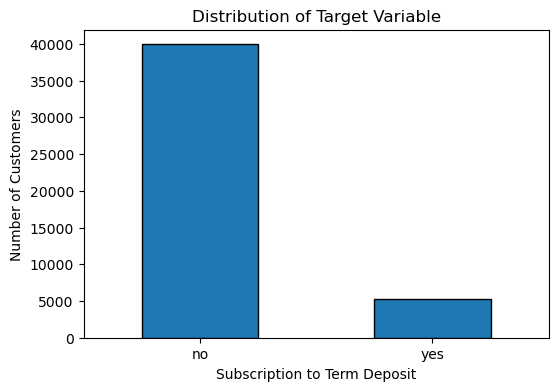

In [339]:
# bar chart
plt.figure(figsize=(6,4))

df["y"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Target Variable")
plt.xlabel("Subscription to Term Deposit")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()

Result: It shows that the maximumn number of customers were not interested to the  term deposit.

In [340]:
# Select numerical columns
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

print(numeric_columns)

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


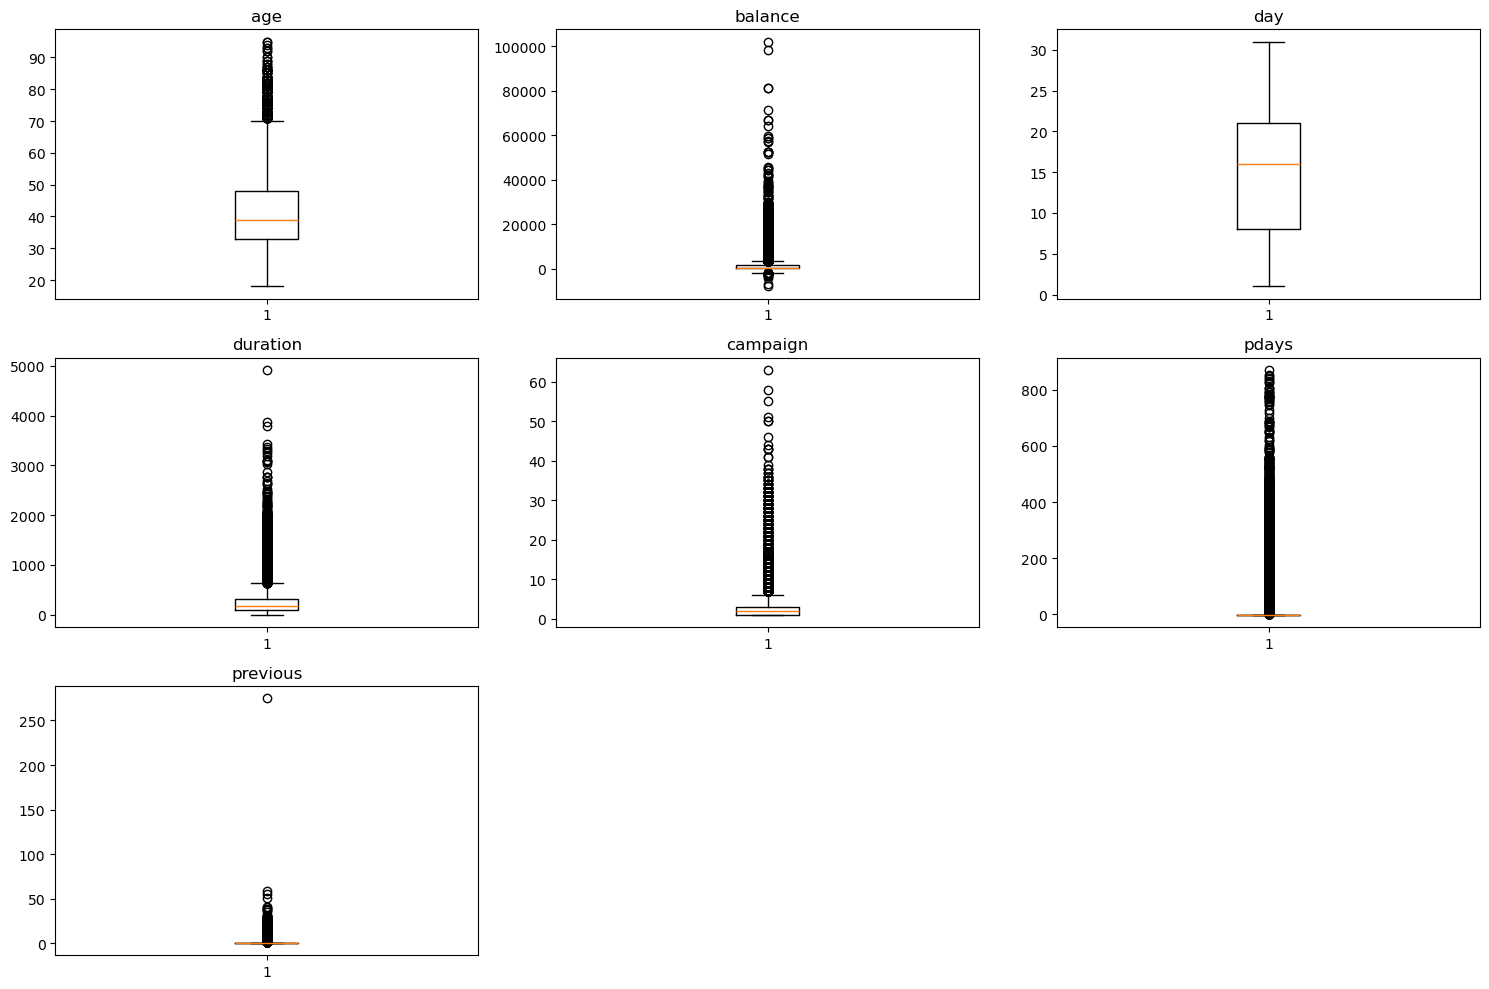

In [341]:
#  Box plot
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    plt.boxplot(df[column], vert=True)
    plt.title(column)

plt.tight_layout()
plt.show()

4.3 Correlation Matrix of Numerical Features

In [342]:
# Select numerical features
numeric_columns = df.select_dtypes(include=["int64", "float64"])

# Calculate correlation matrix
correlation_matrix = numeric_columns.corr()

# Display correlation matrix
correlation_matrix

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


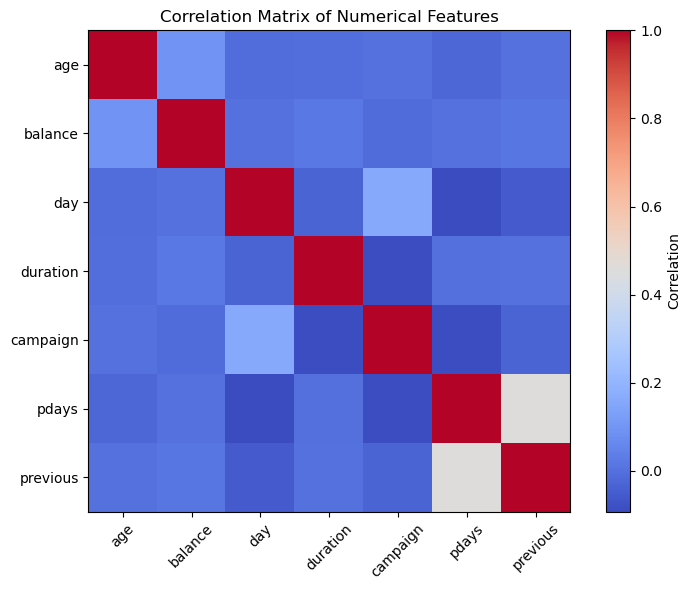

In [343]:

plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()

plt.show()

Result: The correlation matrix shows  relationships between features.There is no strong data overlap present, so all numerical variables were used.

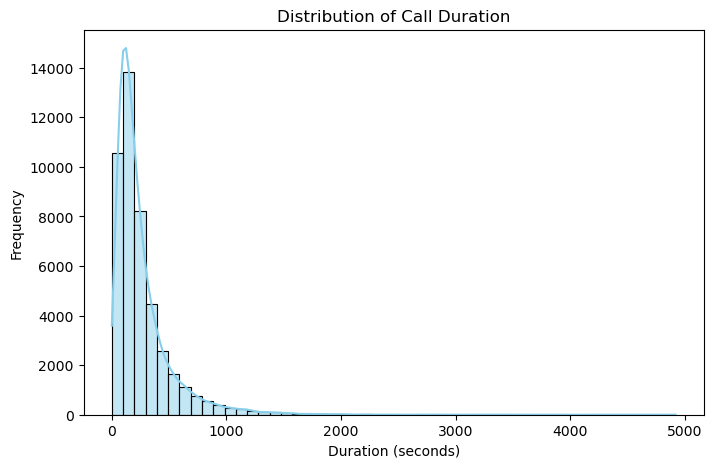

In [344]:
# # Histogram
# numeric_columns = df.select_dtypes(include=np.number).columns

# df[numeric_columns].hist(figsize=(14,10))
# plt.tight_layout()
# plt.show()

import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='duration', bins=50, kde=True, color='skyblue')
plt.title('Distribution of Call Duration')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.show()

Result: The majority of calls are brief, but others are considerably lengthy. This characteristic is typically one of the best indicators of whether a client will sign up for a term deposit.

4.4 Initial Findings

    The dataset contains 45211 customer records and 17 variables.

    The dataset contains both numerical and categorical features. So that different preprocessing methods will be needed before training the models.

    There are no missing (NaN) values in the dataset. Still, some categorical columns contain the value "unknown" and will be handled during data preprocessing.

    No duplicated records were found.

    The target variable (y) is imbalanced. Most customers did not subscribe to a term deposit, while few customer subscribed. Therefore, model performance will be evaluated using metrics such as Precision, Recall, F1-score and ROC-AUC instead of relying only on accuracy.

    The boxplots shows that some numerical variables such as balance, duration and campaign contain outliers. These values appear to represent real customer behaviour, so they will be kept in the dataset.

    The correlation matrix showed that there are no strong relationships between the numerical variables. This means there is no serious multicollinearity problem and all numerical features can be used for model building.

    Since the dataset contains categorical variables like job, education and marital status. These variables will be converted into numerical values using OneHotEncoder before training the models.

## 5. Feature Engineering

Feature engineering focused on preparing existing features by separating data types.

In [345]:
# target distribution
X = df.drop("y", axis=1)

# Target
y = df["y"]
# Convert target to numbers  ← ADD THIS
y = y.map({"no": 0, "yes": 1})

In [346]:
#  Create Feature Lists
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numeric Features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical Features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [347]:
# Strategy B – With Scaling

# Numerical preprocessing pipeline
numeric_transformer_B = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing pipeline
categorical_transformer_B = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numerical and categorical preprocessing
preprocessor_B = ColumnTransformer([
    ("num", numeric_transformer_B, numeric_features),
    ("cat", categorical_transformer_B, categorical_features)
])

** 6. Data Engineering Comparison

In [348]:
# Split the dataset into training (80%) and testing (20%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (36168, 16)
Testing Data: (9043, 16)


**7. Machine Learning Models
    10.1 Introduction

    Machine learning models are used to learn patterns from  data and make predictions for new data. This is a binary classification problem becuase target variable contains two classes with values Yes and No.

   Algorithm: Logistic Regression, Random Forest




In [349]:


# Create the Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

# display midel

print(logistic_model)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


In [350]:
# Create the Random Forest model

rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)
print(rf_model)

RandomForestClassifier(class_weight='balanced', random_state=42)


** 8. Pipeline Construction**
        8.1 Introduction 
        The pipeline combines preprocessing and model training automatically, to make sure that the consistent data handling and best methods to both models.

In [351]:
# Create the Logistic Regression Pipeline
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])
print(logistic_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                  

In [352]:
# Create the Random Forest Pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ))
])

print(rf_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                  

There are various advantages to use a pipeline in project:

1. Both Preprocessing and model training are added into one workflow.

2. It gives us surety that the training and testing data go through the same preparation procedures.

3. It makes  the proccess easy to maintain the notebook and removes duplicate code.

4. It prevent  data leakage because preprocessing is done from the training data and then applied to the test data

5. With  help of GridSearchCV, enabling  model adjustment and preprocessing.

**9. Hyperparameter Tuning using GridSearchCV**
9.1 Introduction

GridSearchCV automatically tests different hyperparameters for logistic regression and Random Forest.

In [353]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV
# Hyperparameter grid for Logistic Regression

param_grid_lr = {
    "model__C": [0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}

In [354]:
# Create GridSearchCV for Logistic Regression
grid_lr = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid_lr,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [355]:
# Train Logistic Regression
grid_lr.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.1, 1, ...], 'model__class_weight': [None, 'balanced'], 'model__solver': ['liblinear', 'lbfgs']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [356]:
# display best parameters
print("Best Parameters:")
print(grid_lr.best_params_)

# cross section validation
print("Best Cross-validation F1 score:")
print(round(grid_lr.best_score_,4))

Best Parameters:
{'model__C': 1, 'model__class_weight': 'balanced', 'model__solver': 'liblinear'}
Best Cross-validation F1 score:
0.5514


In [357]:
# Hyperparameter Grid for Random Forest
param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5]
}

In [358]:
# Create GridSearchCV for Random Forest
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [359]:
# train random set
grid_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [10, 20, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [360]:
# Display Best Parameters
print("Best Parameters:")
print(grid_rf.best_params_)
# display best score of cross validation
print("Best Cross-validation F1-score:")
print(round(grid_rf.best_score_,4))

Best Parameters:
{'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best Cross-validation F1-score:
0.5908


In [361]:
# Step 11.8: Compare the Tuned Models

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Best CV F1 Score": [
        grid_lr.best_score_,
        grid_rf.best_score_
    ]
})

comparison

,Model,Best CV F1 Score
0,Logistic Regression,0.551395
1,Random Forest,0.590784


Observation: Random Forest achieved a higher F1 score (0.590784) compared to Logistic Regression (0.551395).

**10. Model evaluation checks that how  the best Logistic Regression and Random Forest models work on new data. Multiple metrics are used to handle unbalanced data.

In [362]:
# Get the best models from GridSearchCV
best_lr = grid_lr.best_estimator_
best_rf = grid_rf.best_estimator_

In [363]:
# Logistic Regression predictions

y_pred_lr = best_lr.predict(X_test)

# Random Forest predictions

y_pred_rf = best_rf.predict(X_test)

In [364]:
# accuracy score
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

print()

print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy:
0.8457370341700763

Random Forest Accuracy:
0.8983744332632976


In [365]:
# precision
print("Logistic Regression Precision:")
print(precision_score(y_test, y_pred_lr))

print()

print("Random Forest Precision:")
print(precision_score(y_test, y_pred_rf))

Logistic Regression Precision:
0.41824357108199905

Random Forest Precision:
0.5583543240973972


In [366]:
# recall
print("Logistic Regression Recall:")
print(recall_score(y_test, y_pred_lr))

print()

print("Random Forest Recall:")
print(recall_score(y_test, y_pred_rf))

Logistic Regression Recall:
0.8147448015122873

Random Forest Recall:
0.6285444234404537


In [367]:
print("Logistic Regression F1-score:")
print(f1_score(y_test, y_pred_lr))

print()

print("Random Forest F1-score:")
print(f1_score(y_test, y_pred_rf))

Logistic Regression F1-score:
0.5527412632253927

Random Forest F1-score:
0.5913739439751


In [368]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043

Random Forest
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7985
           1       0.56      0.63      0.59      1058

    accuracy                           0.90      9043
   macro avg       0.75      0.78      0.77      9043
weighted avg       0.90      0.90      0.90      9043



Result: It shows the model  predicts most customer results accurately. It balances both precision and recall and making it reliable for subscription predictions.

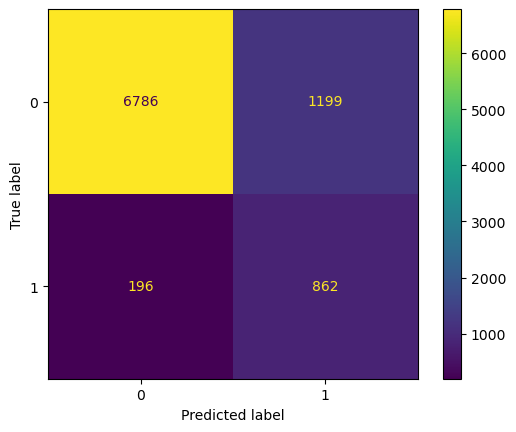

In [369]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_estimator(
    best_lr,
    X_test,
    y_test
)

Result: It shows that most customers were correctly classified. Here, few mistakes indicates that the model gives reliable predictions and works in good way.

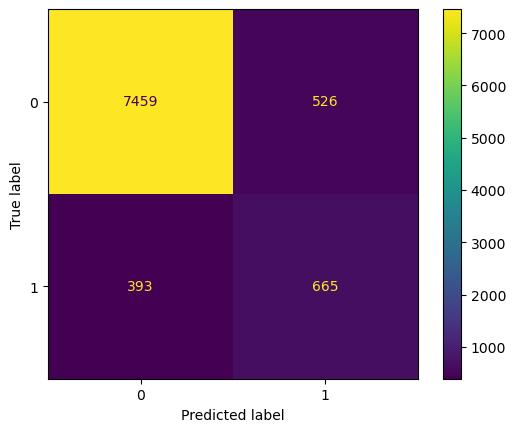

In [370]:
ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test
   
)


Result: It shows that many correct predictions and fewer mistakes than Logistic Regression. It handles complex patterns in better way and gives strong performance.

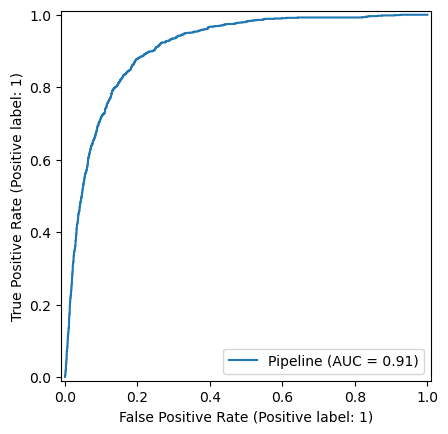

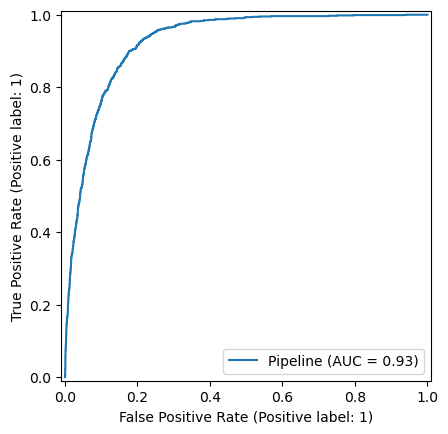

In [371]:
# ROC curv and AUC
RocCurveDisplay.from_estimator(
    best_lr,
    X_test,
    y_test
)

RocCurveDisplay.from_estimator(
    best_rf,
    X_test,
    y_test
)

In [372]:
# Calculate ROC-AUC Scores

# Calculate ROC-AUC score for Logistic Regression
roc_auc_lr = roc_auc_score(
    y_test,
    best_lr.predict_proba(X_test)[:, 1]
)

# Calculate ROC-AUC score for Random Forest
roc_auc_rf = roc_auc_score(
    y_test,
    best_rf.predict_proba(X_test)[:, 1]
)

In [373]:
# Display ROC-AUC Scores

print("Logistic Regression ROC-AUC:")
print(round(roc_auc_lr, 4))

print()

print("Random Forest ROC-AUC:")
print(round(roc_auc_rf, 4))

Logistic Regression ROC-AUC:
0.9079

Random Forest ROC-AUC:
0.9268


In [374]:
# Compare ROC-AUC Scores
roc_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "ROC-AUC Score": [
        roc_auc_lr,
        roc_auc_rf
    ]
})

roc_results

,Model,ROC-AUC Score
0,Logistic Regression,0.907897
1,Random Forest,0.926814


Result: The ROC-AUC score shows that how a model separates customers who will subscribe or not. A higher score means better separation.
Random Forest scored higher value  than Logistic Regression.

In [375]:
#  Feature Importance (Random Forest Only)
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

importance = best_rf.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,num__duration,0.378196
1,num__balance,0.059952
0,num__age,0.058470
2,num__day,0.053706
49,cat__poutcome_success,0.037946
5,num__pdays,0.033317
34,cat__contact_unknown,0.029727
4,num__campaign,0.027926
6,num__previous,0.020998
29,cat__housing_yes,0.020045


Result: Features that score higher value in importance have more influence in decision-making process.

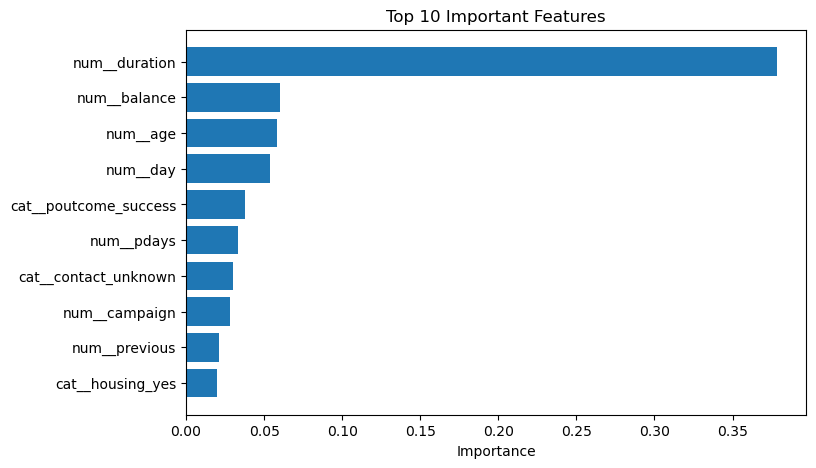

In [376]:
# MODELCOMPARISON TABLE
top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(top10["Feature"], top10["Importance"])

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

The results show that how the logistic regression and random forest models work on new data. Accuracy was giving only general information, but precision, recall and F1-score are more useful because the data is unbalanced.
The confusion matrix shows correct and wrong predictions. ROC-AUC shows how  the models separate the two groups.

**11. Conclusion: 

I created a model to predict if bank customers will take  plan of term deposit. The data was imbalanced (mostly no), so I used precision, recall and F1-score and not relying on accurancy only.

I compared Logistic Regression (85% accuracy, high recall) and Random Forest (90% accuracy, better F1-score of 0.59). Random Forest model performace is good.

Therefore Random forest model can helplot to target the customers.